# Data-Driven Flux-Error Noise Model from Rubin DP1

In this notebook we show how to build a *data-driven* noise model for LightCurveLynx from real [Rubin Data Preview 1 (DP1)](https://dp1.lsst.io) photometry, and then compare it to the built-in physics-based Poisson (shot) noise model when simulating SN Ia light curves.

The workflow has three parts:

1. **Collect a training set with [LSDB](https://docs.lsdb.io).** We stream the DP1 forced difference-image photometry, join it with the per-visit observing metadata, and collect about one million rows stratified by flux, so that both bright and faint observations are well represented.
2. **Train a [pzflow](https://jfcrenshaw.github.io/pzflow/) model** that generates a flux error given the flux and the observing metadata.
3. **Simulate SN Ia light curves** with the data-driven noise model and compare them to the default Poisson-based noise model.

We expect most users to run this notebook on the [Rubin Science Platform (RSP)](https://data.lsst.cloud), where the DP1 catalogs are available under `/rubin/lsdb_data`. The same catalogs are also published for use on other platforms; see [lsdb.io/dp1](https://lsdb.io/dp1) for the available locations and access details. Only the data-collection part needs access to DP1 — the collected table is saved to disk, so the training and simulation parts can run anywhere. On RSP, please prefer the 32GB worker and the latest weekly environment.

Note that several packages used here (e.g. `sncosmo` and `pzflow`) are not installed as part of the default LightCurveLynx installation. You would need via pip (e.g. `pip install pzflow sncosmo`) in order to run this notebook. LSDB may be also required, however it is available on the RSP by default. Access to DP1 also requires Rubin data rights.

In [ ]:
# RSP environment has LSDB installed, but not LightCurveLynx
# %pip install lightcurvelynx pzflow sncosmo

## 1. Get the training data

We start by collecting a flux-stratified training set from the DP1 forced photometry with LSDB. This is the only part of the notebook that needs access to the DP1 catalogs (see the intro); at the end we save the collected table to disk so Parts 2 and 3 can run anywhere.

### 1.1 Setup: imports and a Dask client

LSDB uses [Dask](https://www.dask.org/) to process the catalog in parallel, so we start by creating a Dask client. The settings below are sized for an RSP "Large" container; adjust them for your environment. We also quiet Dask's advisory logging to keep the notebook output readable.

In [2]:
import os
import logging
import warnings

import dask
import lsdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from upath import UPath

# Quiet Dask's advisory logging.
dask.config.set({"logging.distributed": "critical"})
logging.getLogger("distributed").setLevel(logging.CRITICAL)
warnings.filterwarnings("ignore", message="Port 8787 is already in use.")

In [3]:
from dask.distributed import Client

# Sized for an RSP "Large" container. Adjust for your environment.
N_WORKERS = 2
client = Client(
    n_workers=N_WORKERS,
    threads_per_worker=1,
    memory_limit="16GB",
    local_directory=f"/deleted-sundays/{os.environ.get('USER', 'dask_scratch')}",
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://malanchev.nb.data.lsst.cloud/nb/user/malanchev/proxy/8787/status,
Dashboard: https://malanchev.nb.data.lsst.cloud/nb/user/malanchev/proxy/8787/status,Workers: 2
Total threads: 2,Total memory: 29.80 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38587,Workers: 0
Dashboard: https://malanchev.nb.data.lsst.cloud/nb/user/malanchev/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39631,Total threads: 1
Dashboard: https://malanchev.nb.data.lsst.cloud/nb/user/malanchev/proxy/37689/status,Memory: 14.90 GiB
Nanny: tcp://127.0.0.1:44643,


Next we define a few constants used throughout the notebook.

Throughout the notebook we model the difference-image forced photometry
(`psfDiffFlux` / `psfDiffFluxErr`) — the regime that matches the SN Ia
simulation we use as a demonstration in Part 3. pzflow works with numbers
rather than band names, so we describe each band by its effective wavelength
in Angstroms and feed the decimal logarithm of that wavelength to the model
(the `band_wave` column defined later). This lets a single model serve all
six bands.

If you want to model a different photometry regime, there are two independent
choices to make:

- **Which positions are measured.** The *Object* catalog forces photometry at
  the positions of all sources detected on the deep coadds, while the
  *DIA Object* catalog forces it at the positions of sources that appeared or
  varied in the difference images (transients and variables). This choice sets
  the catalog you open in Part 1.2 and the nested forced-source column you
  flatten in Part 1.4.
- **Which image the flux is measured on.** Every forced-source row carries
  both the science-image flux (`psfFlux` / `psfFluxErr`, the total brightness
  of the source) and the difference-image flux (`psfDiffFlux` /
  `psfDiffFluxErr`, the flux relative to the template, which is close to zero
  for a non-varying source). This choice sets the flux and flux-error columns
  you use throughout.

All four combinations are valid and each has its use. Here we use
difference-image photometry at DIA Object positions, which matches transient
science such as supernovae; science-image photometry at DIA Object positions
would instead give the actual flux time series of variable stars or
microlensing events. Pick the pair that matches your science and adjust
Parts 1.2 and 1.4 accordingly. See [lsdb.io/dp1](https://lsdb.io/dp1) for the
available catalogs and their schemas.

In [4]:
BANDS = ["u", "g", "r", "i", "z", "y"]

# Effective wavelengths (Angstroms) used as a numeric encoding of the band. We feed log10 of
# these to the pzflow model (see `band_wave` below).
BAND_WAVE = {"u": 3680.0, "g": 4780.0, "r": 6220.0, "i": 7550.0, "z": 8690.0, "y": 9710.0}

# Inner log-spaced grid over difference flux (nJy), 1e2 .. 1e7, used for the flux distribution
# and for flux stratification.
_FLUX_GRID = np.logspace(2.0, 7.0, 41)

# Full bin edges add an open underflow bin [0, 1e2) and overflow bin [1e7, inf): all
# near-baseline (noise-dominated) epochs collapse into one low bin and all very bright epochs
# into one high bin, instead of being clamped onto the edge in-grid bins.
FLUX_BINS = np.concatenate([[0.0], _FLUX_GRID, [np.inf]])

# Total number of (stratified) forced-source rows we want to collect for training.
TARGET_ROWS = 1_000_000

### 1.2 Open the DP1 DIA Object catalog

We open the `dia_object_collection` HATS catalog, which carries the nested
`diaObjectForcedSource` column with the forced difference-image photometry.
Note that we open the full survey with no spatial filtering: the collection
loop in Part 1.5 streams partitions one at a time and stops as soon as it has
collected `TARGET_ROWS`, so only the partitions we actually need are ever
read.

In [5]:
base_path = UPath("/rubin/lsdb_data")

# Columns we need: the object id/position plus the nested forced-source photometry. We open the
# full survey; the streaming collection in Part 1.5 stops once it has enough rows, so only as
# many partitions as needed are ever read - no need to pre-select a subset here.
dia = lsdb.open_catalog(
    base_path / "dia_object_collection",
    columns=["diaObjectId", "ra", "dec", "nDiaSources", "diaObjectForcedSource"],
)
print(f"Opened the DP1 dia_object catalog ({dia.npartitions} partitions)")
dia

Opened the DP1 dia_object catalog (208 partitions)


,diaObjectId,ra,dec,nDiaSources,diaObjectForcedSource
npartitions=208,,,,,
"Order: 6, Pixel: 130",int64[pyarrow],double[pyarrow],double[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 6, Pixel: 136",...,...,...,...,...
...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...


In [6]:
# The forced photometry is a nested column with its own sub-columns.
print("Nested columns:", dia.nested_columns)
dia["diaObjectForcedSource"].columns

Nested columns: ['diaObjectForcedSource']


['parentObjectId',
 'coord_ra',
 'coord_dec',
 'visit',
 'detector',
 'band',
 'psfFlux',
 'psfFluxErr',
 'psfFlux_flag',
 'psfDiffFlux',
 'psfDiffFluxErr',
 'psfDiffFlux_flag',
 'diff_PixelFlags_nodataCenter',
 'pixelFlags_bad',
 'pixelFlags_cr',
 'pixelFlags_crCenter',
 'pixelFlags_edge',
 'pixelFlags_interpolated',
 'pixelFlags_interpolatedCenter',
 'pixelFlags_nodata',
 'pixelFlags_saturated',
 'pixelFlags_saturatedCenter',
 'pixelFlags_suspect',
 'pixelFlags_suspectCenter',
 'invalidPsfFlag',
 'tract',
 'patch',
 'forcedSourceOnDiaObjectId',
 'psfMag',
 'psfMagErr',
 'midpointMjdTai']

### 1.3 Load the CcdVisit table

The per-visit observing metadata (seeing, exposure time, sky background, sky
noise, and zeropoint) lives in the DP1 CcdVisit table. Unlike the catalog
above, this is a single small parquet table, so we simply download it once
from [data.lsdb.io](https://data.lsdb.io/hats/dp1/) and keep the columns we
need, together with the join keys `(visitId, detector)`.

In [7]:
# Download the DP1 CcdVisit table from data.lsdb.io (once) and read it.
CCDVISIT_PATH = "dp1_ccd_visit.parquet"
if not UPath(CCDVISIT_PATH).exists():
    UPath(CCDVISIT_PATH).write_bytes(UPath("https://data.lsdb.io/hats/dp1/ccd_visit.parquet").read_bytes())

ccdvisit_cols = ["visitId", "detector", "band", "expTime", "seeing", "skyBg", "skyNoise", "zeroPoint"]
visits = pd.read_parquet(CCDVISIT_PATH)[ccdvisit_cols]

# We join forced sources to visits on (visit, detector); the forced-source table already
# carries `band`, so drop the visit-table `band` to avoid a duplicate column on merge.
visits = visits.rename(columns={"visitId": "visit"}).drop(columns=["band"])
visits.head()

,visit,detector,expTime,seeing,skyBg,skyNoise,zeroPoint
0,2024110800245,0,30.0,0.864554,1425.880981,40.684032,31.838995
1,2024110800245,1,30.0,0.823865,1422.503906,37.339367,31.838730
2,2024110800245,2,30.0,0.844020,1418.372925,39.185055,31.836647
3,2024110800245,3,30.0,0.859669,1425.851807,39.428383,31.837961
4,2024110800245,4,30.0,0.808050,1424.323120,39.147896,31.839149


### 1.4 Flatten forced sources and join visit metadata

LSDB lets us apply a function to every HATS partition (patch of the sky). The helper below
converts one partition of the catalog into a flat table with one row per
observation: it explodes the nested `diaObjectForcedSource` column (with
`nested-pandas`'s `.explode()`), merges in the visit metadata on
`(visit, detector)`, and keeps only rows with finite, non-negative difference
fluxes. Negative fluxes are dropped because at simulation time the model is
applied to noise-free model fluxes, which cannot be negative, so we train
only on the non-negative part of the data.

In [8]:
def flatten_partition(partition):
    """Flatten one HATS partition's forced sources and join CcdVisit metadata.

    Returns a flat (per-observation) DataFrame with the difference flux/error, band,
    and the joined observing metadata.
    """
    if len(partition) == 0:
        return _EMPTY_FLAT.copy()

    # One row per forced-source observation.
    flat = partition["diaObjectForcedSource"].explode().reset_index(drop=True)

    # Join the per-visit observing metadata.
    flat = flat.merge(visits, on=["visit", "detector"], how="inner")

    # Keep finite, non-negative difference fluxes (and positive errors). Negatives are
    # dropped: the flux-error relation is asymmetric in the sign of the flux, and the model
    # log-transforms the flux, which needs flux >= 0.
    good = (
        np.isfinite(flat["psfDiffFlux"])
        & np.isfinite(flat["psfDiffFluxErr"])
        & (flat["psfDiffFlux"] >= 0)
        & (flat["psfDiffFluxErr"] > 0)
    )
    flat = flat[good]

    return flat[
        ["band", "psfDiffFlux", "psfDiffFluxErr", "seeing", "expTime", "skyBg", "skyNoise", "zeroPoint"]
    ].reset_index(drop=True)


# Empty, correctly-typed frame returned for empty partitions (used as Dask `meta` too).
_EMPTY_FLAT = pd.DataFrame(
    {
        "band": pd.Series([], dtype="str"),
        "psfDiffFlux": pd.Series([], dtype="float64"),
        "psfDiffFluxErr": pd.Series([], dtype="float64"),
        "seeing": pd.Series([], dtype="float64"),
        "expTime": pd.Series([], dtype="float64"),
        "skyBg": pd.Series([], dtype="float64"),
        "skyNoise": pd.Series([], dtype="float64"),
        "zeroPoint": pd.Series([], dtype="float64"),
    }
)

### 1.5 Stream a flux-stratified training set

Faint observations vastly outnumber bright ones, so a uniform sample would
barely cover the bright end. Instead we give every (band, flux-bin) cell an
equal quota (`target_per_bin`) and fill the quotas as the data comes in.

LSDB's `CatalogStream` makes this easy: it yields the catalog partitions one
chunk at a time, shuffled and pre-fetched in the background. We flatten each
chunk with the helper above, keep rows until each quota fills, and stop as
soon as we have `TARGET_ROWS` in total. This way we never scan the whole
survey and never need to know in advance how many partitions are required.
The same loop also accumulates the flux distributions plotted below.

In [9]:
import math
from collections import defaultdict

from lsdb.streams import CatalogStream

# Roughly equal number of rows in every (band, flux-bin) cell.
n_bins = len(FLUX_BINS) - 1
target_per_bin = math.ceil(TARGET_ROWS / (len(BANDS) * n_bins))

# CatalogStream yields a chunk of partitions at a time, shuffled and pre-fetched on the Dask
# client. We use partitions_per_chunk = N_WORKERS so every worker stays busy; we then flatten
# each chunk, fill the per-(band, bin) quotas, and stop at TARGET_ROWS. The fixed seed makes
# the partition order and within-partition shuffle reproducible.
stream = CatalogStream(catalog=dia, client=client, partitions_per_chunk=N_WORKERS, shuffle=True, seed=42)

filled = defaultdict(int)  # (band, bin) -> rows kept so far
raw_counts = defaultdict(int)  # (band, bin) -> rows seen, for the distribution plot
collected = _EMPTY_FLAT.copy()
n_chunks = 0

for chunk in stream:
    n_chunks += 1
    flat = flatten_partition(chunk)
    if len(flat) == 0:
        continue
    flat = flat.assign(_bin=np.digitize(flat["psfDiffFlux"], FLUX_BINS) - 1)

    # Raw (pre-quota) distribution from the chunks we actually stream.
    for (band, b), c in flat.groupby(["band", "_bin"]).size().items():
        raw_counts[(band, int(b))] += int(c)

    # CatalogStream already shuffles rows within each chunk; keep up to each
    # (band, bin)'s remaining quota and accumulate into the running training set.
    within = flat.groupby(["band", "_bin"]).cumcount().to_numpy()
    remaining = np.array(
        [target_per_bin - filled[(band, int(b))] for band, b in zip(flat["band"], flat["_bin"])]
    )
    kept = flat.loc[within < remaining]
    if len(kept):
        collected = pd.concat([collected, kept.drop(columns="_bin")], ignore_index=True)
        for (band, b), c in kept.groupby(["band", "_bin"]).size().items():
            filled[(band, int(b))] += int(c)

    if len(collected) >= TARGET_ROWS:
        break

# Per-band raw histogram (all bins, incl. the open under/overflow bins) for the plot below.
flux_hist = (
    pd.Series(raw_counts, dtype="int64")
    .rename_axis(index=["band", "bin"])
    .rename("count")
    .unstack("bin")
    .reindex(index=BANDS, columns=range(n_bins))
    .fillna(0)
)

print(
    f"Streamed {n_chunks} chunks ({N_WORKERS} partitions each); collected {len(collected):,} rows "
    f"across {sum(v > 0 for v in filled.values())} (band, bin) cells"
)
collected.head()

/tmp/ipykernel_608/1932871295.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  collected = pd.concat([collected, kept.drop(columns="_bin")], ignore_index=True)


Streamed 104 chunks (2 partitions each); collected 803,642 rows across 248 (band, bin) cells


,band,psfDiffFlux,psfDiffFluxErr,seeing,expTime,skyBg,skyNoise,zeroPoint
0,y,329.763489,1368.264404,0.861185,30.0,4173.868652,65.506180,30.382305
1,y,952.81897,1291.732666,0.782433,30.0,4251.874512,66.215729,30.383390
2,y,460.594788,1250.75,0.749716,30.0,4255.135254,66.952919,30.387461
3,i,339.088074,301.289032,0.902741,30.0,3027.087891,57.383926,31.829393
4,i,383.655609,299.569519,0.894787,30.0,3042.063721,58.556870,31.830231


Let's plot the per-band flux distributions: the raw one we saw while
streaming (solid) and the stratified one (dashed). The raw distribution is
completely dominated by the faint end. The stratified counts are exactly
`target_per_bin` in every bin where the quota filled — the same number for
all bands, so the dashed curves overlap there — and follow the raw counts in
the bins that ran out of data, mostly at the bright end.

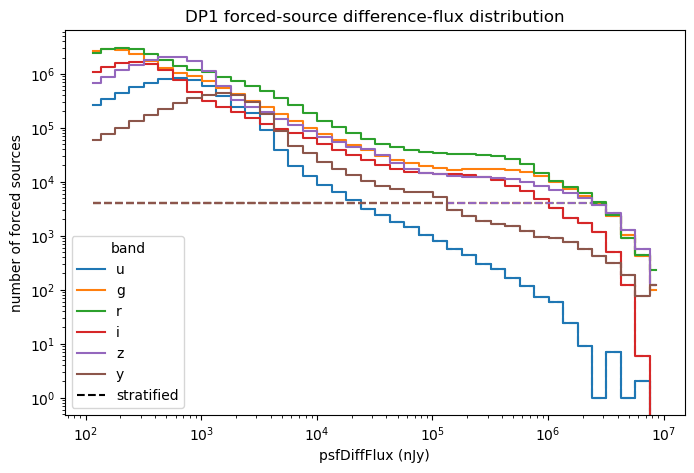

In [10]:
from matplotlib.lines import Line2D

# Geometric centres of the inner (finite) flux bins. The open under/overflow bins (first and
# last columns of the histograms) have no finite centre, so they are omitted from this plot.
bin_centers = np.sqrt(_FLUX_GRID[:-1] * _FLUX_GRID[1:])

# Per-band histogram of the rows we kept after the stratified selection.
kept_hist = (
    pd.Series(filled, dtype="int64")
    .rename_axis(index=["band", "bin"])
    .rename("count")
    .unstack("bin")
    .reindex(index=BANDS, columns=range(n_bins))
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(8, 5))
for band in BANDS:
    (line,) = ax.step(bin_centers, flux_hist.loc[band].to_numpy()[1:-1], where="mid", label=band)
    ax.step(
        bin_centers,
        kept_hist.loc[band].to_numpy()[1:-1],
        where="mid",
        ls="--",
        color=line.get_color(),
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("psfDiffFlux (nJy)")
ax.set_ylabel("number of forced sources")
ax.set_title("DP1 forced-source difference-flux distribution")

# The dashed (stratified) curves sit exactly on the same per-bin quota line wherever it is
# reached, so they overlap almost everywhere; label the style once in the legend.
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color="k", ls="--"))
labels.append("stratified")
ax.legend(handles, labels, title="band")
plt.show()

Finally, we add the numeric band encoding, rename the metadata columns to the
names LightCurveLynx's `ObsTable` will use at simulation time, and save the
table to disk. From this point on, the notebook no longer needs LSDB or DP1
access.

In [11]:
training_table = collected.rename(
    columns={
        "psfDiffFlux": "bandflux",  # pzflow feeds the simulated flux to a column named "bandflux"
        "expTime": "exptime",
        "skyBg": "sky_bg_adu",
        "skyNoise": "sky_noise_adu",
        "zeroPoint": "zp_mag_adu",
    }
)
# log10 of the effective wavelength (Angstroms) as the numeric band encoding.
training_table["band_wave"] = np.log10(training_table["band"].map(BAND_WAVE))

# Save so the training/simulation sections can run anywhere.
training_table.to_parquet("dp1_noise_training_table.parquet")
training_table.head()

,band,bandflux,psfDiffFluxErr,seeing,exptime,sky_bg_adu,sky_noise_adu,zp_mag_adu,band_wave
0,y,329.763489,1368.264404,0.861185,30.0,4173.868652,65.506180,30.382305,3.987219
1,y,952.81897,1291.732666,0.782433,30.0,4251.874512,66.215729,30.383390,3.987219
2,y,460.594788,1250.75,0.749716,30.0,4255.135254,66.952919,30.387461,3.987219
3,i,339.088074,301.289032,0.902741,30.0,3027.087891,57.383926,31.829393,3.877947
4,i,383.655609,299.569519,0.894787,30.0,3042.063721,58.556870,31.830231,3.877947


### 1.6 Visualize: flux vs flux-error per band

Let's look at the data we have collected: a 2D histogram of `psfDiffFlux` vs
`psfDiffFluxErr` for each band. This joint distribution is exactly what the
pzflow model will learn to reproduce.

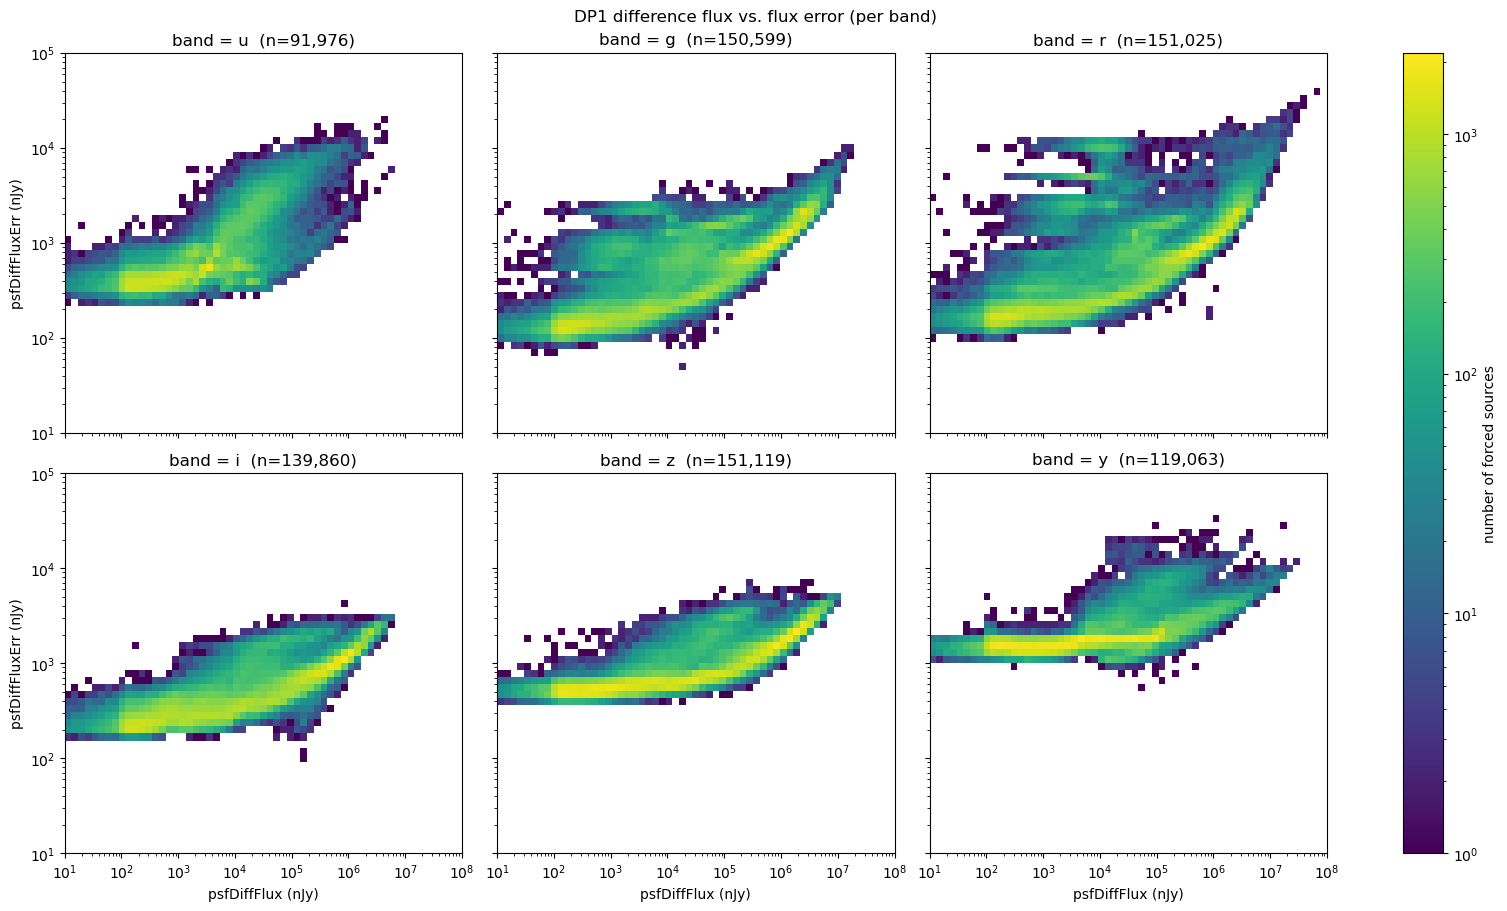

In [12]:
from matplotlib.colors import LogNorm

flux_edges = np.logspace(1, 8, 60)
err_edges = np.logspace(1, 5, 55)

# Pre-histogram every band so all panels share one color scale (and thus one colorbar).
hists = {
    band: np.histogram2d(sub["bandflux"], sub["psfDiffFluxErr"], bins=[flux_edges, err_edges])[0]
    for band in BANDS
    if len(sub := training_table[training_table["band"] == band])
}
vmax = max((h.max() for h in hists.values()), default=1.0)
norm = LogNorm(vmin=1, vmax=vmax)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True, constrained_layout=True)
mesh = None
for ax, band in zip(axes.ravel(), BANDS):
    sub = training_table[training_table["band"] == band]
    if len(sub) == 0:
        ax.set_title(f"{band} (no data)")
        continue
    _, _, _, mesh = ax.hist2d(
        sub["bandflux"],
        sub["psfDiffFluxErr"],
        bins=[flux_edges, err_edges],
        cmap="viridis",
        cmin=1,
        norm=norm,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"band = {band}  (n={len(sub):,})")

for ax in axes[-1]:
    ax.set_xlabel("psfDiffFlux (nJy)")
for ax in axes[:, 0]:
    ax.set_ylabel("psfDiffFluxErr (nJy)")
if mesh is not None:
    fig.colorbar(mesh, ax=axes, label="number of forced sources")
fig.suptitle("DP1 difference flux vs. flux error (per band)")
plt.show()

## 2. Train the pzflow noise model

Now we fit a single conditional normalizing flow that generates a flux error
given the flux and the observing metadata. This part only needs the training
table saved above.

### 2.1 Train the conditional flow

We train the flow with LightCurveLynx's `learn_pzflow_noise_model` function.
The target column (`noise_column`) is the flux error, `psfDiffFluxErr`; every
other column of the table is a conditional input: the flux (`bandflux`), the
numeric band encoding (`band_wave`), and the observing metadata. Before
training we set aside a random 20% of the rows as a test split, so in
Part 2.3 we can validate the model on data it has never seen.

Note that `learn_pzflow_noise_model` log-transforms the target and the
`bandflux` column, so it cannot handle fluxes `<= 0`. Real difference fluxes
are routinely negative, but the noise-free model fluxes we apply the noise
model to at simulation time are not, so we dropped the negative fluxes when
collecting the data (Part 1.4). Simulated fluxes can still reach exactly
zero; Part 3.3 describes how the model handles that automatically.

In [13]:
from lightcurvelynx.noise_models.pzflow_noise_model import learn_pzflow_noise_model

model_df = training_table[
    [
        "bandflux",
        "band_wave",
        "seeing",
        "exptime",
        "sky_bg_adu",
        "sky_noise_adu",
        "zp_mag_adu",
        "psfDiffFluxErr",
    ]
].dropna()

# Hold out a random 20% test split the flow never sees, so the validation in Part 2.3 is an
# honest check on unseen rows rather than a re-fit of the training data.
test_df = model_df.sample(frac=0.2, random_state=42)
train_df = model_df.drop(index=test_df.index)
print(f"Training on {len(train_df):,} rows; holding out {len(test_df):,} for validation")

noise_model = learn_pzflow_noise_model(train_df, noise_column="psfDiffFluxErr", normalize=True)

# Persist the trained model for reuse.
noise_model.save_to_file("dp1_pzflow_noise_model.pkl")

Training on 642,793 rows; holding out 160,698 for validation


### 2.2 Sanity check: data vs. sampled flux error

As a quick first check, we sample flux errors from the trained model for one
band, conditioned on the real fluxes and observing parameters, and overplot
them on the data.

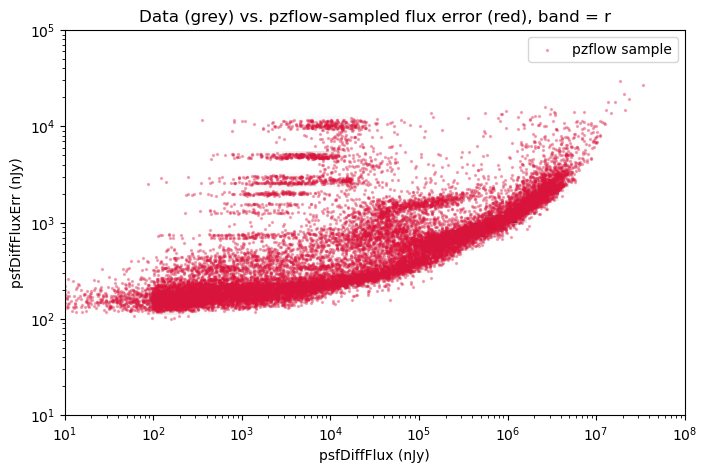

In [14]:
check_band = "r"
sub = train_df.assign(band=training_table.loc[train_df.index, "band"])
sub = sub[sub["band"] == check_band]

# Draw model flux-error samples conditioned on the real observing parameters of this band.
sample_n = min(20_000, len(sub))
cond = sub.sample(n=sample_n, random_state=0)
predicted_err = []
# apply_noise expects an ObsTable; here we sample the flow directly for the sanity check.
flow_inputs = cond[
    ["bandflux", "band_wave", "seeing", "exptime", "sky_bg_adu", "sky_noise_adu", "zp_mag_adu"]
]
for col, norm in noise_model._normalizer_data.items():
    if col in flow_inputs and norm is not None:
        flow_inputs = flow_inputs.assign(**{col: norm.normalize(flow_inputs[col])})
samples = noise_model._flow.sample(nsamples=1, conditions=flow_inputs, seed=0)
err_norm = noise_model._normalizer_data["psfDiffFluxErr"]
predicted_err = err_norm.denormalize(samples["psfDiffFluxErr"].to_numpy())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist2d(sub["bandflux"], sub["psfDiffFluxErr"], bins=[flux_edges, err_edges], cmap="Greys", cmin=1)
ax.scatter(cond["bandflux"], predicted_err, s=2, color="crimson", alpha=0.3, label="pzflow sample")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("psfDiffFlux (nJy)")
ax.set_ylabel("psfDiffFluxErr (nJy)")
ax.set_title(f"Data (grey) vs. pzflow-sampled flux error (red), band = {check_band}")
ax.legend()
plt.show()

### 2.3 How well did pzflow learn the data?

Now a stronger check. For every row of the held-out test split (the 20% set
aside in Part 2.1) we draw one flux-error sample conditioned on that row's
real flux and observing metadata, and compare the distribution of the sampled
errors to the real ones in every band. We bin by flux and overlay the median
and the 16-84% range of the data (black) and of the pzflow samples (red). If
the bands overlap, the flow has reproduced both the flux-error relation and
its scatter on data it never saw during training.

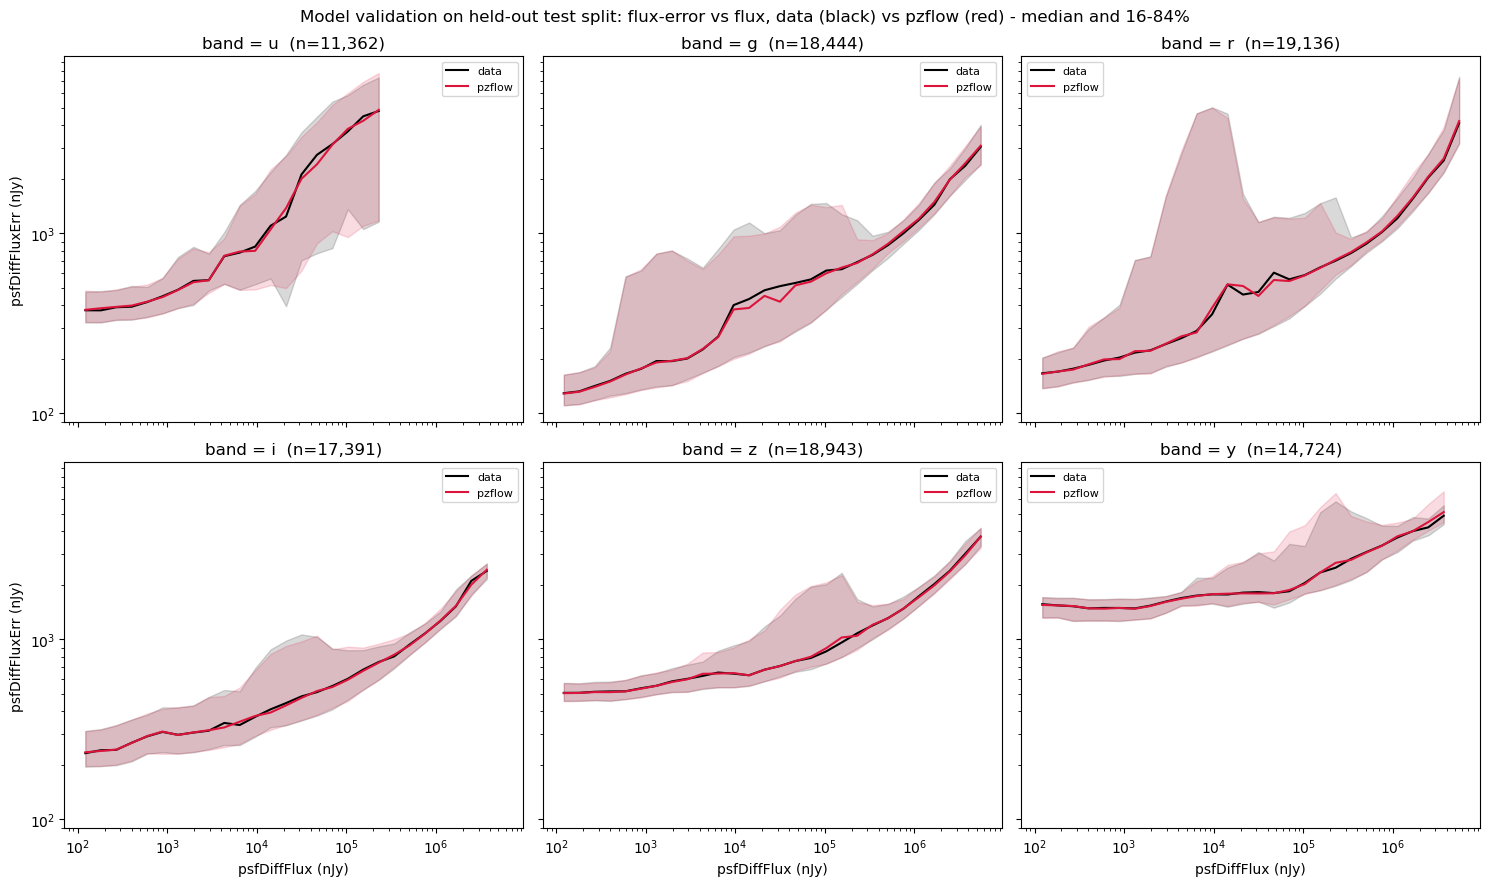

In [15]:
def sample_model_err(df, seed=0):
    """Draw one pzflow flux-error sample per row, conditioned on that row's inputs."""
    cond = df[
        ["bandflux", "band_wave", "seeing", "exptime", "sky_bg_adu", "sky_noise_adu", "zp_mag_adu"]
    ].copy()
    for col, norm in noise_model._normalizer_data.items():
        if col in cond and norm is not None:
            cond[col] = norm.normalize(cond[col])
    samples = noise_model._flow.sample(nsamples=1, conditions=cond, seed=seed)
    return noise_model._normalizer_data["psfDiffFluxErr"].denormalize(samples["psfDiffFluxErr"].to_numpy())


# Conditioned model sample for a (subsampled) copy of the held-out test split.
val = test_df.assign(band=training_table.loc[test_df.index, "band"])
if len(val) > 100_000:
    val = val.sample(n=100_000, random_state=1)
val = val.assign(model_err=sample_model_err(val, seed=1))

# Median and 16-84% of the error vs flux, in log-flux bins.
val_bins = np.logspace(2, 7, 30)
val_centers = np.sqrt(val_bins[:-1] * val_bins[1:])


def pct_curve(x, y, q, min_count=50):
    idx = np.digitize(x, val_bins) - 1
    out = np.full(len(val_centers), np.nan)
    for i in range(len(val_centers)):
        m = idx == i
        if m.sum() >= min_count:
            out[i] = np.percentile(y[m], q)
    return out


fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
for ax, band in zip(axes.ravel(), BANDS):
    sub = val[val["band"] == band]
    if len(sub) == 0:
        ax.set_title(f"{band} (no data)")
        continue
    x = sub["bandflux"].to_numpy()
    for col, color, label in [("psfDiffFluxErr", "k", "data"), ("model_err", "crimson", "pzflow")]:
        y = sub[col].to_numpy()
        ax.fill_between(val_centers, pct_curve(x, y, 16), pct_curve(x, y, 84), color=color, alpha=0.15)
        ax.plot(val_centers, pct_curve(x, y, 50), "-", color=color, label=label)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"band = {band}  (n={len(sub):,})")
    ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("psfDiffFlux (nJy)")
for ax in axes[:, 0]:
    ax.set_ylabel("psfDiffFluxErr (nJy)")
fig.suptitle(
    "Model validation on held-out test split: flux-error vs flux, data (black) vs pzflow (red) - median and 16-84%"
)
fig.tight_layout()
plt.show()

## 3. Simulate and compare

Finally, we use the trained flow as a drop-in LightCurveLynx noise model in
an SN Ia simulation, and compare it against the built-in physics-based
Poisson noise model.

### 3.1 Build the simulation ObsTable and passbands

For the simulation we turn the same DP1 CcdVisit table into a LightCurveLynx
`LSSTObsTable`, which maps the DP1 columns to the names the noise models
expect (e.g. `band` becomes `filter`, `skyBg` becomes `sky_bg_adu`). We then
add the two extra columns the pzflow model was trained with: the numeric band
encoding (`band_wave`) and the sky noise (`sky_noise_adu`), which is not part
of the standard column mapping.

We will get an expected warning from the fact that the DP1 CcdVisit table has
NaNs in some of the columns the noise models rely on (such as seeing and sky
background), so we drop those visits first.

In [16]:
from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable

survey_data = pd.read_parquet(CCDVISIT_PATH)

# The DP1 CcdVisit table has NaNs in some noise columns. The noise models reject NaNs in
# their required columns, so drop visits missing the values we need before building the table.
survey_data = survey_data.dropna(subset=["seeing", "skyBg", "skyNoise", "zeroPoint", "pixelScale"])

obs_table = LSSTObsTable.from_ccdvisit_table(survey_data, make_detector_footprint=True)

# Add the numeric band encoding used as a conditional input by the pzflow model:
# log10 of the effective wavelength (Angstroms), matching the training table.
band_wave_col = np.array([np.log10(BAND_WAVE[f]) if f in BAND_WAVE else np.nan for f in obs_table["filter"]])
obs_table.add_column("band_wave", band_wave_col, overwrite=True)

# skyNoise is not in the LSSTObsTable column map, so expose it under the training-table name.
# The ObsTable preserves original columns, so rows remain aligned.
obs_table.add_column("sky_noise_adu", np.asarray(obs_table["skyNoise"], dtype=float), overwrite=True)

print(f"Loaded {len(obs_table)} CCD-visit rows")
obs_table.columns.tolist()

Loaded 15994 CCD-visit rows


['detectorId',
 'visitId',
 'physical_filter',
 'filter',
 'ra',
 'dec',
 'pixel_scale',
 'zenithDistance',
 'exptime',
 'zp_mag_adu',
 'psfSigma',
 'sky_bg_adu',
 'skyNoise',
 'astromOffsetMean',
 'astromOffsetStd',
 'nPsfStar',
 'psfStarDeltaE1Median',
 'psfStarDeltaE2Median',
 'psfStarDeltaE1Scatter',
 'psfStarDeltaE2Scatter',
 'psfStarDeltaSizeMedian',
 'psfStarDeltaSizeScatter',
 'psfStarScaledDeltaSizeScatter',
 'psfTraceRadiusDelta',
 'psfApFluxDelta',
 'psfApCorrSigmaScaledDelta',
 'maxDistToNearestPsf',
 'effTime',
 'effTimePsfSigmaScale',
 'effTimeSkyBgScale',
 'effTimeZeroPointScale',
 'maglim',
 'decl',
 'ccdVisitId',
 'detector',
 'seeing',
 'rotation',
 'expMidpt',
 'time',
 'obsStart',
 'obsStartMJD',
 'darkTime',
 'xSize',
 'ySize',
 'llcra',
 'llcdec',
 'ulcra',
 'ulcdec',
 'urcra',
 'urcdec',
 'lrcra',
 'lrcdec',
 'radius',
 'zp',
 'psf_footprint',
 'sky_bg_e',
 'band_wave',
 'sky_noise_adu']

In [17]:
from lightcurvelynx.astro_utils.passbands import PassbandGroup

# On RSP this will download the LSST passbands; pass table_dir= to use a cached copy.
passband_group = PassbandGroup.from_preset(preset="LSST")

### 3.2 Build the SN Ia source

We build a standard SALT-based SN Ia source using the LightCurveLynx
`snia_utils` helpers, drawing positions around the DP1 field center and `t0`
within the observed time range. For a step-by-step walkthrough of this setup,
see the
[SN Ia notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/simple_snia.html).

In [18]:
from lightcurvelynx.astro_utils.snia_utils import DistModFromRedshift, HostmassX1Func, X0FromDistMod
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.extrapolate import LinearDecay

# Field center and time range from the obs table.
field_ra = float(np.median(obs_table["ra"]))
field_dec = float(np.median(obs_table["dec"]))
t_min = float(np.min(obs_table["time"]))
t_max = float(np.max(obs_table["time"]))

host = SNIaHost(
    ra=NumpyRandomFunc("uniform", low=field_ra - 0.3, high=field_ra + 0.3),
    dec=NumpyRandomFunc("uniform", low=field_dec - 0.3, high=field_dec + 0.3),
    hostmass=NumpyRandomFunc("uniform", low=7, high=12),
    redshift=NumpyRandomFunc("uniform", low=0.05, high=0.4),
    node_label="host",
)

distmod_func = DistModFromRedshift(host.redshift, H0=73.0, Omega_m=0.3)
x1_func = HostmassX1Func(host.hostmass)
c_func = NumpyRandomFunc("normal", loc=0, scale=0.02)
m_abs_func = NumpyRandomFunc("normal", loc=-19.3, scale=0.1)
x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=0.14,
    beta=3.1,
    m_abs=m_abs_func,
    node_label="x0_func",
)

source = SncosmoWrapperModel(
    "salt3",
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=host.ra,
    dec=host.dec,
    redshift=host.redshift,
    node_label="source",
    time_extrapolation=LinearDecay(50.0),
)

### 3.3 Simulate with both noise models

We build two `SurveyInfo` objects over the same observations and passbands:
one with the default Poisson noise model, and one with our trained pzflow
model. We simulate the same set of SN Ia with each (same random seed), so the
only difference between the two outputs is the noise.

Simulated fluxes can be zero (e.g. far from the supernova peak), which the
model's log-transform cannot handle. `PZFlowNoiseModel` takes care of this
automatically: fluxes below the smallest flux seen in training are raised to
that value for the flux-error sampling (below it the flow would be
extrapolating anyway), while the noise itself is still centered on the
original flux. Pass `flux_floor=` to `learn_pzflow_noise_model` to choose the
bound yourself.

In [19]:
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.survey_info import SurveyInfo

N_SNE = 25
SEED = 42

# Baseline: default (Poisson) noise model for LSST.
survey_poisson = SurveyInfo(obstable=obs_table, passbands=passband_group, survey_name="LSST")

# Data-driven: our trained pzflow noise model. Its conditional inputs (band_wave, seeing,
# exptime, sky_bg_adu, sky_noise_adu, zp_mag_adu) match the obs-table column names.
survey_pzflow = SurveyInfo(
    obstable=obs_table,
    passbands=passband_group,
    noise_model=noise_model,
    survey_name="LSST",
)

lc_poisson = simulate_lightcurves(
    source, N_SNE, survey_poisson, rest_time_window_offset=(-50, 100), rng=np.random.default_rng(SEED)
)
lc_pzflow = simulate_lightcurves(
    source, N_SNE, survey_pzflow, rest_time_window_offset=(-50, 100), rng=np.random.default_rng(SEED)
)
lc_pzflow.head()

Simulating:   0%|          | 0/25 [00:00<?, ?obj/s]

Simulating:  44%|████▍     | 11/25 [00:00<00:00, 103.84obj/s]

Simulating:  88%|████████▊ | 22/25 [00:00<00:00, 101.12obj/s]

Simulating: 100%|██████████| 25/25 [00:00<00:00, 103.90obj/s]

Simulating:   0%|          | 0/25 [00:00<?, ?obj/s]

...

Simulating:  88%|████████▊ | 22/25 [00:40<00:05,  1.81s/obj]

Simulating:  92%|█████████▏| 23/25 [00:42<00:03,  1.88s/obj]

Simulating:  96%|█████████▌| 24/25 [00:44<00:01,  1.94s/obj]

Simulating: 100%|██████████| 25/25 [00:44<00:00,  1.79s/obj]

id         ra        dec  nobs            t0         z  \
0   0  53.474148 -28.212457   524  60653.328942  0.119968   
1   1  53.273102 -28.049208   762  60646.416055  0.052577   
2   2  53.524933 -28.302958   365  60632.057763  0.325424   
3   3  53.428195 -28.236667   581  60655.334419  0.282698   
4   4  53.066281 -27.919411   783  60649.032090  0.296808   

                                          lightcurve  \
0  [{mjd: 60623.258521, filter: 'i', flux: -31.02...   
1  [{mjd: 60623.258521, filter: 'i', flux: -262.9...   
2  [{mjd: 60623.258521, filter: 'i', flux: 6791.0...   
3  [{mjd: 60623.258521, filter: 'i', flux: 49.407...   
4  [{mjd: 60623.258521, filter: 'i', flux: 23.520...   

                                              params  
0  {'NumpyRandomFunc:uniform_2.low': 53.009774565...  
1  {'NumpyRandomFunc:uniform_2.low': 53.009774565...  
2  {'NumpyRandomFunc:uniform_2.low': 53.009774565...  
3  {'NumpyRandomFunc:uniform_2.low': 53.009774565...  
4  {'NumpyRandomFunc:uniform_2.low': 53.009774565...

### 3.4 Compare the two noise models

First, let's look at a single simulated supernova. The top panel shows its
noise-free light curve. The bottom panel shows, for every observation, the
ratio of the flux error assigned by the data-driven model to the Poisson one,
plotted against the noise-free flux: points above the dashed line are
observations where the data-driven model predicts larger errors than Poisson,
and points below are where it predicts smaller ones. Plotting against flux
shows how the difference between the two models depends on the flux.

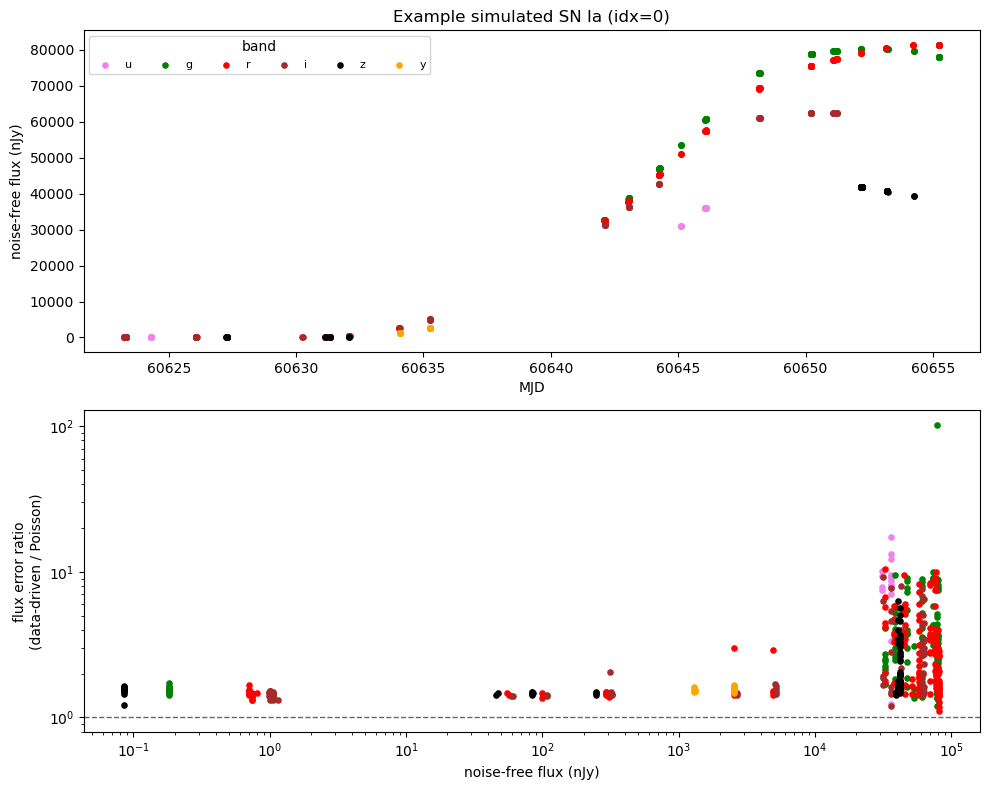

In [20]:
idx = 0
colors = {"u": "violet", "g": "green", "r": "red", "i": "brown", "z": "black", "y": "orange"}

row_p = lc_poisson.iloc[idx]["lightcurve"]
row_z = lc_pzflow.iloc[idx]["lightcurve"]

fig, (ax_lc, ax_ratio) = plt.subplots(2, 1, figsize=(10, 8))

for band in BANDS:
    mp = np.asarray(row_p["filter"], dtype=str) == band
    mz = np.asarray(row_z["filter"], dtype=str) == band
    if not mp.any():
        continue

    # Both models simulate the same obs table for the same object, so per band the
    # observations match; sort each by MJD to pair them element-wise.
    mjd = np.asarray(row_p["mjd"], dtype=float)[mp]
    perfect = np.asarray(row_p["flux_perfect"], dtype=float)[mp]
    err_p = np.asarray(row_p["fluxerr"], dtype=float)[mp]
    err_z = np.asarray(row_z["fluxerr"], dtype=float)[mz]
    op = np.argsort(mjd)
    oz = np.argsort(np.asarray(row_z["mjd"], dtype=float)[mz])

    # Top: noise-free light curve (points only, no connecting lines) versus time.
    ax_lc.scatter(mjd, perfect, s=14, color=colors[band], label=band)
    # Bottom: per-observation error ratio versus noise-free flux.
    ax_ratio.scatter(perfect[op], err_z[oz] / err_p[op], s=14, color=colors[band])

ax_lc.set_xlabel("MJD")
ax_lc.set_ylabel("noise-free flux (nJy)")
ax_lc.set_title(f"Example simulated SN Ia (idx={idx})")
ax_lc.legend(title="band", ncol=6, fontsize=8)

ax_ratio.axhline(1.0, color="0.4", lw=1, ls="--")
ax_ratio.set_xscale("log")
ax_ratio.set_yscale("log")
ax_ratio.set_xlabel("noise-free flux (nJy)")
ax_ratio.set_ylabel("flux error ratio\n(data-driven / Poisson)")

fig.tight_layout()
plt.show()

Now we compare the flux errors the two models assign across all simulated
observations in each band. Any offset between the two point clouds shows
where the data-driven model differs from the Poisson prediction.

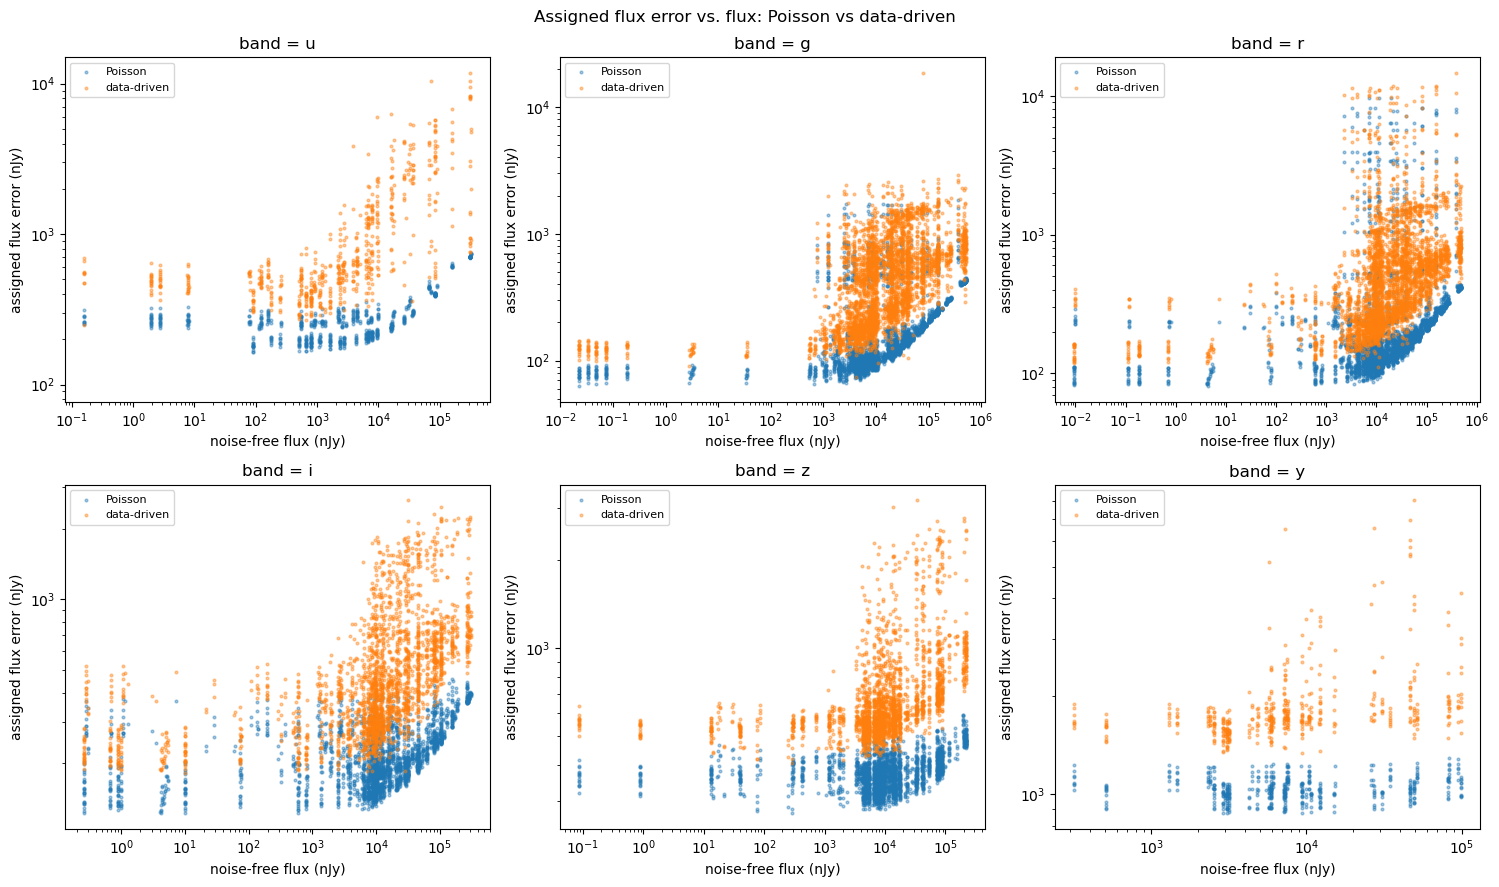

In [21]:
def stack_obs(lc):
    """Stack all observations from a simulated-lightcurve frame into flat arrays."""
    filt, flux, err = [], [], []
    for i in range(len(lc)):
        row = lc.iloc[i]["lightcurve"]
        filt.append(np.asarray(row["filter"], dtype=str))
        flux.append(np.asarray(row["flux_perfect"], dtype=float))
        err.append(np.asarray(row["fluxerr"], dtype=float))
    return np.concatenate(filt), np.concatenate(flux), np.concatenate(err)


f_p, flux_p, err_p = stack_obs(lc_poisson)
f_z, flux_z, err_z = stack_obs(lc_pzflow)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, band in zip(axes.ravel(), BANDS):
    mp = f_p == band
    mz = f_z == band
    if not mp.any():
        ax.set_title(f"{band} (no obs)")
        continue
    ax.scatter(flux_p[mp], err_p[mp], s=4, alpha=0.4, label="Poisson")
    ax.scatter(flux_z[mz], err_z[mz], s=4, alpha=0.4, label="data-driven")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"band = {band}")
    ax.set_xlabel("noise-free flux (nJy)")
    ax.set_ylabel("assigned flux error (nJy)")
    ax.legend(fontsize=8)
fig.suptitle("Assigned flux error vs. flux: Poisson vs data-driven")
fig.tight_layout()
plt.show()

## Conclusion

We collected a flux-stratified training set from real Rubin DP1 forced
photometry with LSDB, trained a pzflow model to generate flux errors from the
flux and observing metadata, and used it as a drop-in noise model in a
LightCurveLynx SN Ia simulation. The resulting `PZFlowNoiseModel` can be used
like any other noise model, so the same approach extends to other source
models and surveys.

A few things to revisit when adapting this notebook to your own science case:

- Which photometry to model: difference-image (`psfDiffFlux`, used here) or
  science-image (`psfFlux`), and at which positions (see the discussion in
  Part 1).
- The `psfDiffFlux >= 0` filtering (Part 1.4) and the flux floor applied at
  simulation time (Part 3.3).
- The flux-stratification scheme and the `TARGET_ROWS` budget (Part 1.5).
- The pzflow training hyperparameters, passed through
  `learn_pzflow_noise_model`.